# **TP 2 : CNN Architecture**

**Objectifs du TP**

familiarisation avec les architectures des réseau de neurones convolutifs et leur utilisation en Python pour la classification d’image en utilisant la bibliothèque keras.

# **1- Téléchargement de Dataset**

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# **2- Section des imports**

In [2]:
import os
from keras import backend as K
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D
from keras.layers import Activation, Flatten, Dense
import matplotlib.pyplot as plt

# **3- Section des paramètres**

In [3]:
# Changer le répertoire de travail vers le dossier où les données sont stockées
os.chdir('/content/drive/MyDrive/v_data')

# Définir la taille des images (Largeur x Hauteur) pour le modèle CNN
img_width, img_height = 224, 224

# Chemins vers les dossiers d'entraînement et de validation
train_data_dir = 'images/train'
validation_data_dir = 'images/test'

# Nombre d'échantillons dans les ensembles d'entraînement et de validation
nb_train_samples = 400
nb_validation_samples = 100

# Paramètres d'entraînement du modèle
epochs = 15          # Nombre de passes sur l'ensemble du dataset
batch_size = 16      # Nombre d'échantillons traités avant mise à jour des poids

# Paramètres du CNN
num_filters = 8      # Nombre de filtres pour la première couche convolutionnelle
filter_size = 3      # Taille des filtres (3x3)

# Définir la forme de l'entrée selon le format des images dans Keras
# 'channels_first' = (canaux, largeur, hauteur)
# 'channels_last'  = (largeur, hauteur, canaux)
if K.image_data_format() == 'channels_first':
    input_shape = (3, img_width, img_height)
else:
    input_shape = (img_width, img_height, 3)

In [4]:
# Importer ImageDataGenerator pour générer des lots d'images avec augmentation
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# ------------------ Préparation des données d'entraînement ------------------
# Appliquer la normalisation et des transformations pour augmenter le dataset
train_datagen = ImageDataGenerator(
    rescale=1./255,       # Normaliser les pixels entre 0 et 1
    shear_range=0.2,      # Appliquer un cisaillement aléatoire pour augmenter les données
    zoom_range=0.2,       # Appliquer un zoom aléatoire
    horizontal_flip=True  # Retourner horizontalement certaines images
)

# ------------------ Préparation des données de validation ------------------
# Seulement normalisation, pas d'augmentation
test_datagen = ImageDataGenerator(rescale=1./255)

# Définir les chemins vers les dossiers d'entraînement et de validation
train_data_dir = '/content/drive/MyDrive/v_data/train'
validation_data_dir = '/content/drive/MyDrive/v_data/test'

# ------------------ Générateur d'images pour l'entraînement ------------------
train_generator = train_datagen.flow_from_directory(
    train_data_dir,                   # Dossier contenant les images d'entraînement
    target_size=(img_width, img_height),  # Redimensionner toutes les images
    batch_size=batch_size,            # Nombre d'images par lot
    class_mode='categorical'          # Mode catégoriel pour classification multi-classes
)

# ------------------ Générateur d'images pour la validation ------------------
validation_generator = test_datagen.flow_from_directory(
    validation_data_dir,              # Dossier contenant les images de test
    target_size=(img_width, img_height),  # Redimensionner toutes les images
    batch_size=batch_size,            # Nombre d'images par lot
    class_mode='categorical'          # Mode catégoriel
)

Found 400 images belonging to 2 classes.
Found 100 images belonging to 2 classes.


# **4- Section architecture du CNN**

In [5]:
# Importer les couches nécessaires de Keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Activation

# ------------------ Construction du modèle CNN ------------------
model = Sequential()  # Initialiser le modèle séquentiel

# 1- Couche Convolutionnelle
# num_filters filtres de taille 3x3 appliqués à l'image d'entrée
model.add(Conv2D(num_filters, (3,3), input_shape=input_shape))
model.add(Activation('relu'))  # Fonction d'activation ReLU pour introduire la non-linéarité

# 2- Couche de Max Pooling
# Réduit la taille des cartes de caractéristiques et extrait les informations les plus importantes
model.add(MaxPooling2D(pool_size=(2, 2)))

# 3- Aplatir les cartes de caractéristiques pour la couche Dense
model.add(Flatten())  # Transforme les matrices 2D en vecteur 1D

# 4- Couche Dense intermédiaire
# 24 neurones entièrement connectés pour apprendre les patterns complexes
model.add(Dense(24))
model.add(Activation('relu'))  # Activation ReLU pour cette couche dense

# 5- Couche de sortie
# 2 neurones pour la classification binaire (ex: qualité ou classe du vin)
model.add(Dense(2))
model.add(Activation('sigmoid'))  # Sigmoid pour sortie entre 0 et 1 pour classification binaire

# Afficher le résumé du modèle avec le nombre de paramètres par couche
print(model.summary())

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 8)    │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 222, 222, 8)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 8)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 98568)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 24)             │     2,365,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 24)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │            50 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 2)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,365,930 (9.03 MB)

 Trainable params: 2,365,930 (9.03 MB)

 Non-trainable params: 0 (0.00 B)

None


# **Section entrainement du modèle et évaluation**

In [6]:
# ------------------ Compilation du modèle ------------------
# Ici on définit la fonction de perte, l'optimiseur et les métriques d'évaluation
model.compile(
    loss='binary_crossentropy',  # Fonction de perte pour classification binaire
    optimizer='rmsprop',         # Optimiseur RMSprop, efficace pour CNN
    metrics=['accuracy']         # On suit l'accuracy pour mesurer la performance
)

# ------------------ Entraînement du modèle ------------------
# history contiendra les valeurs de loss et accuracy pour chaque epoch
history = model.fit(
    train_generator,                       # Générateur des données d'entraînement
    steps_per_epoch=nb_train_samples // batch_size,  # Nombre de batches par epoch
    epochs=epochs,                          # Nombre total d'epochs
    validation_data=validation_generator,   # Générateur des données de validation
    validation_steps=nb_validation_samples // batch_size  # Nombre de batches de validation
)

Epoch 1/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 105s 4s/step - accuracy: 0.5775 - loss: 1.8225 - val_accuracy: 0.6042 - val_loss: 0.5743
Epoch 2/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 17s 667ms/step - accuracy: 0.7025 - loss: 0.5738 - val_accuracy: 0.8438 - val_loss: 0.4359
Epoch 3/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 18s 686ms/step - accuracy: 0.7750 - loss: 0.5056 - val_accuracy: 0.8958 - val_loss: 0.3285
Epoch 4/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 20s 772ms/step - accuracy: 0.8275 - loss: 0.4277 - val_accuracy: 0.8333 - val_loss: 0.3972
Epoch 5/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 17s 648ms/step - accuracy: 0.8550 - loss: 0.3851 - val_accuracy: 0.8958 - val_loss: 0.3019
Epoch 6/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 21s 659ms/step - accuracy: 0.8525 - loss: 0.3527 - val_accuracy: 0.8333 - val_loss: 0.3840
Epoch 7/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 16s 658ms/step - accuracy: 0.8725 - loss: 0.3244 - val_accuracy: 0.9062 - val_loss: 0.2947
Epoch 8/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 21s 672ms/step - accuracy: 0.8625 - loss: 0.3428 - val_accura

#**Section visualisation**

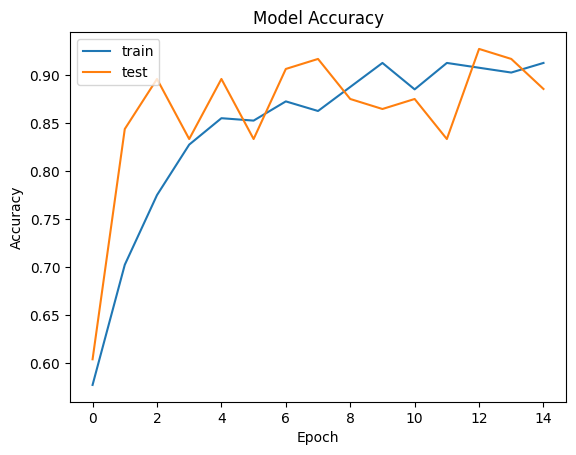

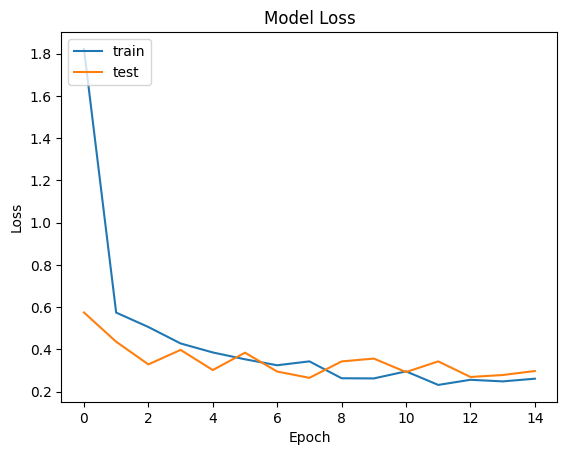

In [7]:
# ------------------ Visualisation de l'accuracy ------------------
plt.plot(history.history['accuracy'])       # Accuracy sur l'ensemble d'entraînement
plt.plot(history.history['val_accuracy'])   # Accuracy sur l'ensemble de validation
plt.title('Model Accuracy')                 # Titre du graphique
plt.ylabel('Accuracy')                      # Label axe Y
plt.xlabel('Epoch')                         # Label axe X
plt.legend(['train', 'test'], loc='upper left')  # Légende
plt.show()                                  # Affiche le graphique

# ------------------ Visualisation de la loss ------------------
plt.plot(history.history['loss'])           # Loss sur l'ensemble d'entraînement
plt.plot(history.history['val_loss'])       # Loss sur l'ensemble de validation
plt.title('Model Loss')                     # Titre du graphique
plt.ylabel('Loss')                          # Label axe Y
plt.xlabel('Epoch')                         # Label axe X
plt.legend(['train', 'test'], loc='upper left')  # Légende
plt.show()                                  # Affiche le graphique